In [1]:
from sklearn.datasets import load_breast_cancer
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import Perceptron, SGDClassifier
from utils import plot_decision_boundary

cancer = load_breast_cancer()
X, y = cancer.data, cancer.target
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

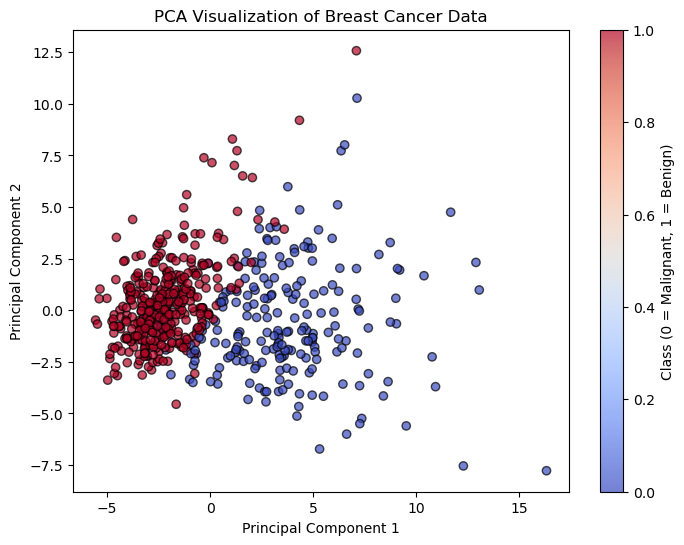

In [2]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap="coolwarm", edgecolors="k", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization of Breast Cancer Data")
plt.colorbar(label="Class (0 = Malignant, 1 = Benign)")
plt.show()

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(
    X_pca, y, test_size=0.2, random_state=42
)

# With original feature dimensions


## Perceptron


In [4]:
perceptron = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perceptron.fit(X_train, y_train)

y_pred_perceptron = perceptron.predict(X_test)
accuracy_perceptron = accuracy_score(y_test, y_pred_perceptron)

## Average Perceptron


In [5]:
avg_perceptron = SGDClassifier(
    loss="perceptron", max_iter=1000, tol=1e-3, average=True, random_state=42
)
avg_perceptron.fit(X_train, y_train)

y_pred_avg_perceptron = avg_perceptron.predict(X_test)
accuracy_avg_perceptron = accuracy_score(y_test, y_pred_avg_perceptron)

## Pegasos


In [6]:
pegasos = SGDClassifier(
    loss="hinge", max_iter=1000, tol=1e-3, alpha=0.01, random_state=42
)
pegasos.fit(X_train, y_train)

y_pred_pegasos = pegasos.predict(X_test)
accuracy_pegasos = accuracy_score(y_test, y_pred_pegasos)

# With PCA dimensioned data


## Perceptron

In [7]:
perceptron_pca = Perceptron(max_iter=1000, tol=1e-3, random_state=42)
perceptron_pca.fit(X_train_pca, y_train_pca)
accuracy_perceptron_pca = accuracy_score(y_test_pca, perceptron_pca.predict(X_test_pca))

## Average Perceptron

In [8]:
avg_perceptron_pca = SGDClassifier(loss="perceptron", max_iter=1000, tol=1e-3, average=True, random_state=42)
avg_perceptron_pca.fit(X_train_pca, y_train_pca)
accuracy_avg_perceptron_pca = accuracy_score(y_test_pca, avg_perceptron_pca.predict(X_test_pca))

## Pegasos


In [9]:
pegasos_pca = SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, alpha=0.01, random_state=42)
pegasos_pca.fit(X_train_pca, y_train_pca)
accuracy_pegasos_pca = accuracy_score(y_test_pca, pegasos_pca.predict(X_test_pca))

# Results

In [10]:
print("\n🔍 Model Comparison:")
print(f"Perceptron Accuracy (Original): {accuracy_perceptron:.4f}")
print(f"Perceptron Accuracy (PCA): {accuracy_perceptron_pca:.4f}")
print(f"Averaged Perceptron Accuracy (Original): {accuracy_avg_perceptron:.4f}")
print(f"Averaged Perceptron Accuracy (PCA): {accuracy_avg_perceptron_pca:.4f}")
print(f"Pegasos (SVM) Accuracy (Original): {accuracy_pegasos:.4f}")
print(f"Pegasos (SVM) Accuracy (PCA): {accuracy_pegasos_pca:.4f}")


🔍 Model Comparison:
Perceptron Accuracy (Original): 0.9737
Perceptron Accuracy (PCA): 0.9561
Averaged Perceptron Accuracy (Original): 0.9825
Averaged Perceptron Accuracy (PCA): 0.9912
Pegasos (SVM) Accuracy (Original): 0.9825
Pegasos (SVM) Accuracy (PCA): 0.9649


## Plotting (PCA only)

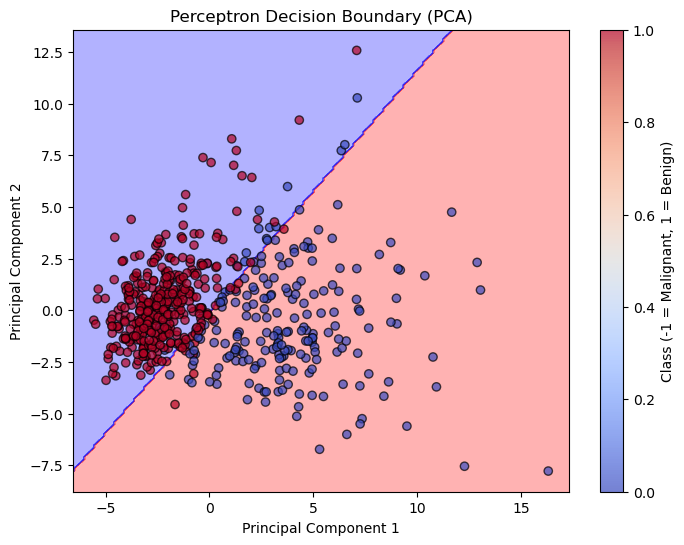

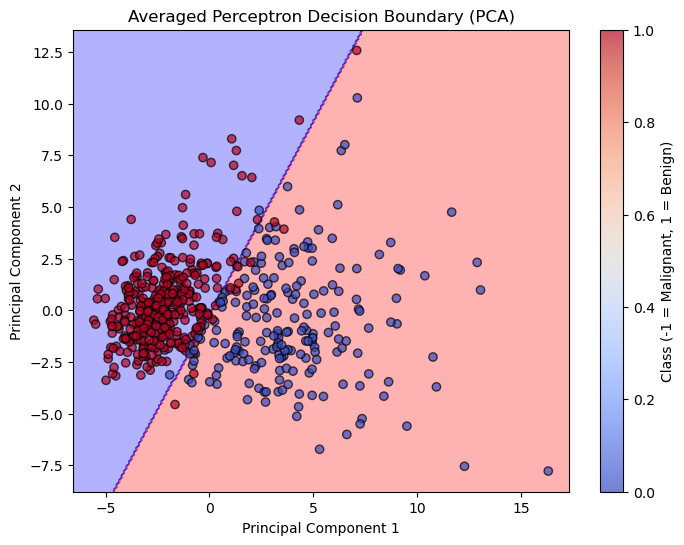

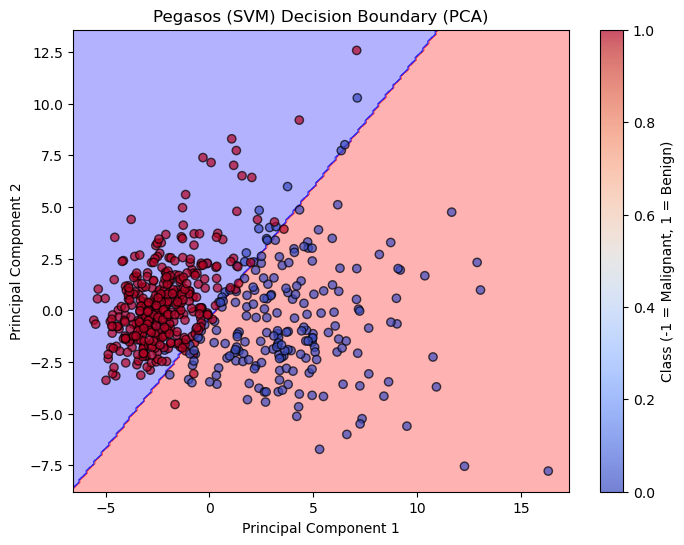

In [11]:
plot_decision_boundary(perceptron_pca, X_pca, y, "Perceptron Decision Boundary (PCA)")
plot_decision_boundary(avg_perceptron_pca, X_pca, y, "Averaged Perceptron Decision Boundary (PCA)")
plot_decision_boundary(pegasos_pca, X_pca, y, "Pegasos (SVM) Decision Boundary (PCA)")